In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import os

In [ ]:
#Load the meetings dataset
meetings_df = pd.read_csv('../data/raw/Montagna_Meetings_Edgelist.csv')
print(meetings_df.shape)
print(meetings_df.columns)
meetings_df.head()

(289, 1)
Index(['Source Target Weight'], dtype='str')


,Source Target Weight
0,N0 N1 1
1,N0 N2 1
2,N1 N2 1
3,N3 N4 1
4,N3 N5 1


In [3]:
meetings_df[['Source', 'Target', 'Weight']] = meetings_df['Source Target Weight'].str.split(' ', expand=True)

# Convert 'Weight' to numeric
meetings_df['Weight'] = pd.to_numeric(meetings_df['Weight'], errors='coerce')

# Set all column names in lowercase
meetings_df.columns = meetings_df.columns.str.lower()

meetings_df.drop(columns=['source target weight'], inplace=True)
meetings_df.head()

,source,target,weight
0,N0,N1,1
1,N0,N2,1
2,N1,N2,1
3,N3,N4,1
4,N3,N5,1


In [4]:
nodes = pd.unique(meetings_df[['source', 'target']].values.ravel())

node_mapping = {node: i for i, node in enumerate(nodes)}

meetings_df['source_id'] = meetings_df['source'].map(node_mapping)
meetings_df['target_id'] = meetings_df['target'].map(node_mapping)

In [5]:
node_mapping

{'N0': 0,
 'N1': 1,
 'N2': 2,
 'N3': 3,
 'N4': 4,
 'N5': 5,
 'N6': 6,
 'N7': 7,
 'N8': 8,
 'N9': 9,
 'N10': 10,
 'N11': 11,
 'N12': 12,
 'N13': 13,
 'N14': 14,
 'N68': 15,
 'N16': 16,
 'N17': 17,
 'N18': 18,
 'N19': 19,
 'N20': 20,
 'N21': 21,
 'N22': 22,
 'N23': 23,
 'N24': 24,
 'N25': 25,
 'N26': 26,
 'N27': 27,
 'N28': 28,
 'N29': 29,
 'N30': 30,
 'N31': 31,
 'N32': 32,
 'N33': 33,
 'N34': 34,
 'N35': 35,
 'N36': 36,
 'N61': 37,
 'N70': 38,
 'N39': 39,
 'N40': 40,
 'N41': 41,
 'N42': 42,
 'N43': 43,
 'N47': 44,
 'N45': 45,
 'N46': 46,
 'N48': 47,
 'N49': 48,
 'N50': 49,
 'N51': 50,
 'N52': 51,
 'N96': 52,
 'N54': 53,
 'N55': 54,
 'N56': 55,
 'N57': 56,
 'N59': 57,
 'N60': 58,
 'N62': 59,
 'N63': 60,
 'N64': 61,
 'N65': 62,
 'N66': 63,
 'N67': 64,
 'N69': 65,
 'N71': 66,
 'N72': 67,
 'N73': 68,
 'N74': 69,
 'N75': 70,
 'N76': 71,
 'N77': 72,
 'N78': 73,
 'N79': 74,
 'N80': 75,
 'N81': 76,
 'N82': 77,
 'N83': 78,
 'N84': 79,
 'N85': 80,
 'N86': 81,
 'N87': 82,
 'N88': 83,
 'N89': 84,


In [6]:
meetings_df.head()

,source,target,weight,source_id,target_id
0,N0,N1,1,0,1
1,N0,N2,1,0,2
2,N1,N2,1,1,2
3,N3,N4,1,3,4
4,N3,N5,1,3,5


In [7]:
# Create the graph
G = ig.Graph.DataFrame(meetings_df[['source_id', 'target_id', 'weight']], directed=False)
layout = 'fr'
print(G.summary())

IGRAPH U-W- 95 289 -- 
+ attr: weight (e)


In [8]:
edge_widths = [w * 0.2 for w in G.es['weight']]

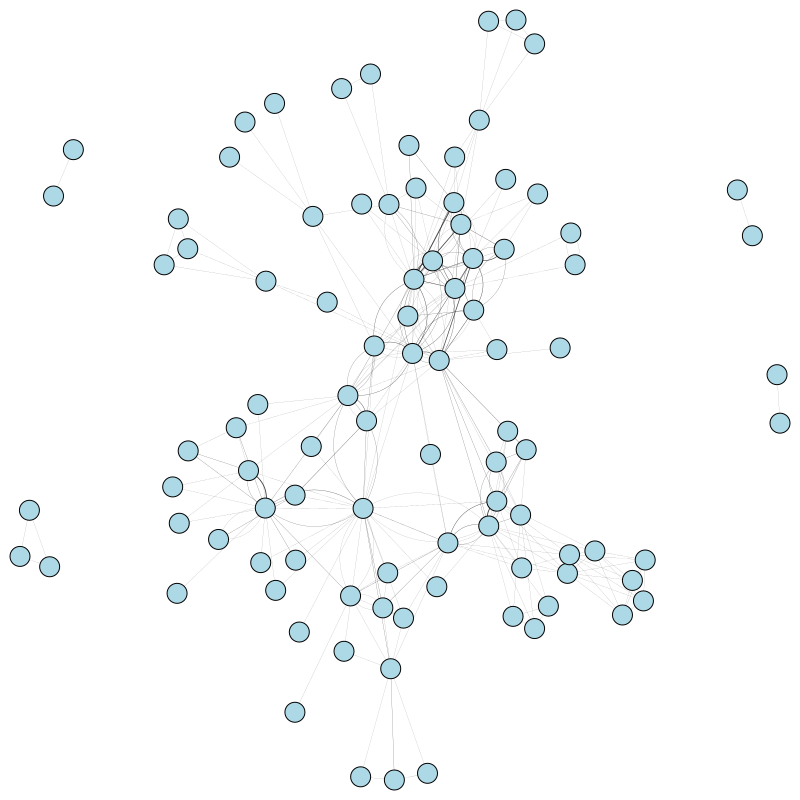

In [9]:
ig.plot(
    G,
    vertex_size=20,
    vertex_color='lightblue',
    edge_width=[w * 0.1 for w in G.es['weight']],
    layout='fr',
    bbox=(800, 800)
)

In [10]:
# Adding Montagna Roles as names
roles = pd.read_csv('../data/Montagna_Roles.csv')
roles.head()

,Node,Role,Relationship,Request
0,N0,cooperating witness,NaN,NaN
1,N1,NaN,conversation with 0,NaN
2,N2,boss family ''Barcellona Pozzo di Gotto'',NaN,NaN
3,N3,boss family ''Caltagirone'',NaN,NaN
4,N4,enterpreneur,NaN,NaN


In [11]:
# Create a new column for families - they are within "" - some of they are NaN

roles['Family'] = roles['Role'].astype(str).str.extract(r'boss family\s+(.+)', expand=False)
roles['Family'] = roles['Family'].str.strip().fillna('Unknown')

roles.head()

,Node,Role,Relationship,Request,Family
0,N0,cooperating witness,NaN,NaN,Unknown
1,N1,NaN,conversation with 0,NaN,Unknown
2,N2,boss family ''Barcellona Pozzo di Gotto'',NaN,NaN,''Barcellona Pozzo di Gotto''
3,N3,boss family ''Caltagirone'',NaN,NaN,''Caltagirone''
4,N4,enterpreneur,NaN,NaN,Unknown


In [12]:
# Using Roles for naming vertices
role_mapping = dict(zip(roles['Node'], roles['Role']))
G.vs['name'] = [role_mapping.get(node, str(node)) for node in nodes]

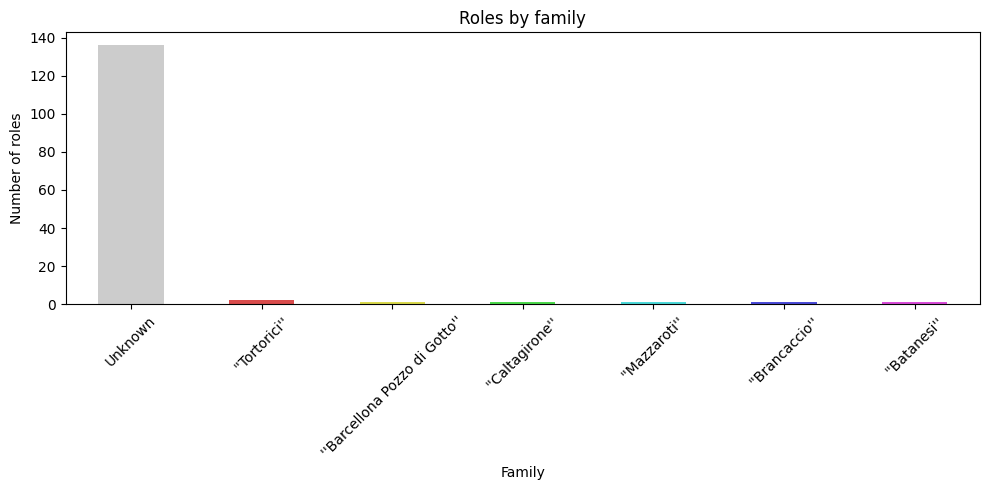

In [13]:
import colorsys

family_counts = roles['Family'].value_counts().sort_values(ascending=False)
families = [family for family in family_counts.index if family != 'Unknown']

def generate_distinct_colors(n, s=0.65, v=0.85):
    return [colorsys.hsv_to_rgb(i / n, s, v) for i in range(n)] if n > 0 else []

family_colors = dict(zip(families, generate_distinct_colors(len(families))))
family_colors['Unknown'] = (0.8, 0.8, 0.8)

fig, ax = plt.subplots(figsize=(10, 5))
family_counts.plot(
    kind='bar',
    ax=ax,
    color=[family_colors[family] for family in family_counts.index]
)
ax.set_title('Roles by family')
ax.set_xlabel('Family')
ax.set_ylabel('Number of roles')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

family_mapping = roles.drop_duplicates('Node').set_index('Node')['Family'].to_dict()
G.vs['family'] = [family_mapping.get(node, 'Unknown') for node in nodes]

G.vs['color'] = [family_colors[f] for f in G.vs['family']]

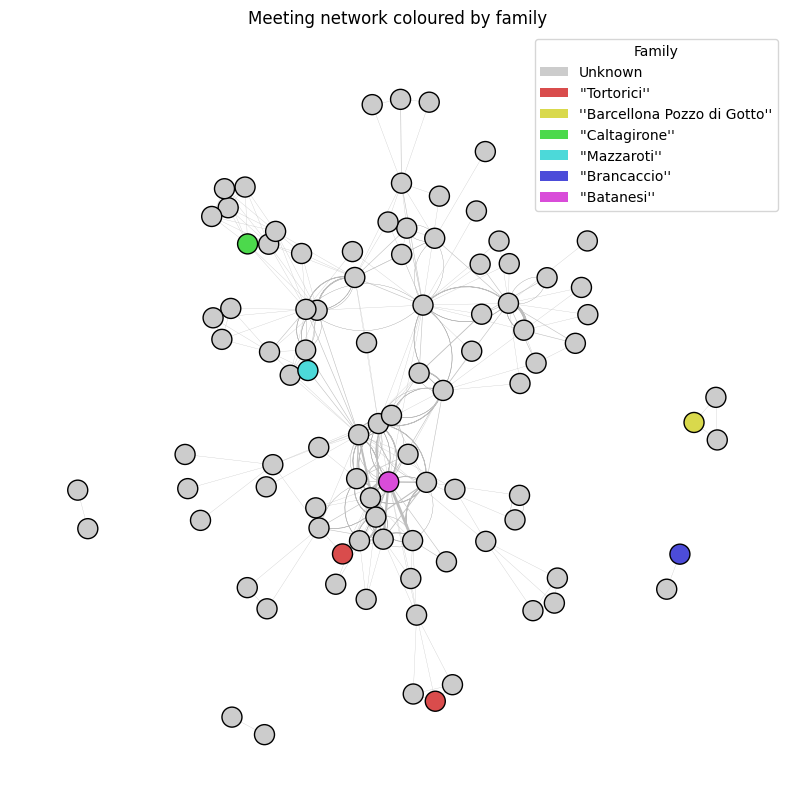

In [14]:
# Visualize the graph

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 10))

ig.plot(
    G,
    target=ax,
    layout=layout,
    vertex_size=20,
    vertex_color=G.vs['color'],
    edge_width=edge_widths,
    edge_color='gray',
    bbox=(800, 800)
)

legend_elements = [
    Patch(facecolor=family_colors[fam], label=fam)
    for fam in family_counts.index
]

ax.set_title('Meeting network coloured by family')
ax.legend(handles=legend_elements, title="Family", loc='upper right')
plt.show()


In [15]:
# Get centrality measures
degrees = G.degree()
betweenness = G.betweenness()
closeness = G.closeness()


In [16]:
# Get the top 5 nodes by degree
top_degree_nodes = sorted(zip(G.vs['name'], degrees), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 nodes by degree:")
for name, degree in top_degree_nodes:
    print(f"{name}: {degree}")
    
G.vs['name'] = [name if name in [node[0] for node in top_degree_nodes] else '' for name in G.vs['name']]

Top 5 nodes by degree:
executive family ''Mistretta'': 28
deputy boss family ''Batanesi'': 26
executive family ''Batanesi'': 24
executive family ''Batanesi'': 22
member family ''Mistretta'': 20


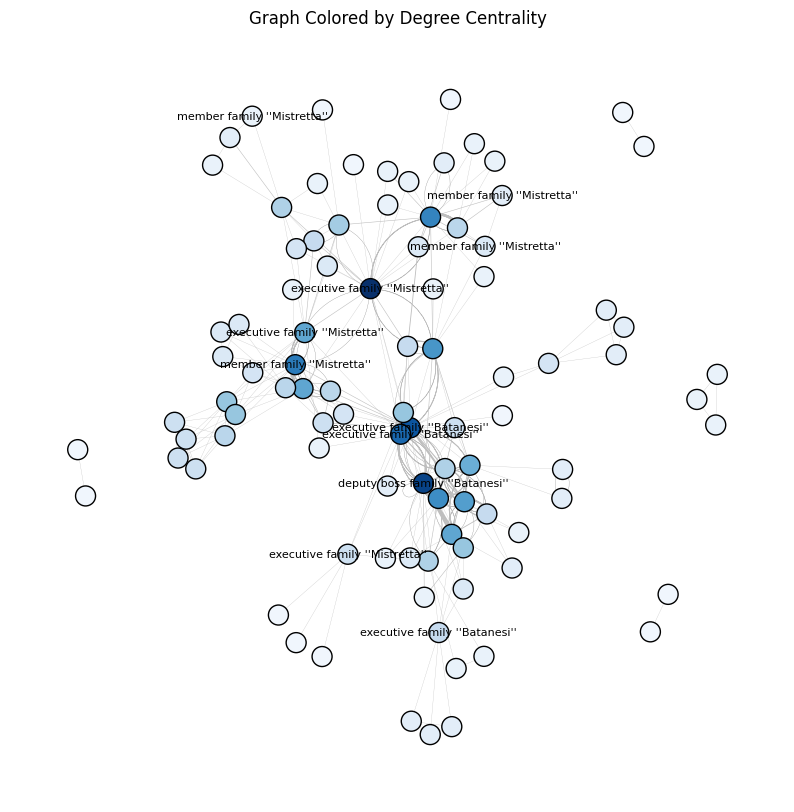

In [17]:
# Color nodes by degree
degree_colors = [plt.cm.Blues(deg / max(degrees)) for deg in degrees]

# Visualize the graph with degree-based coloring
fig, ax = plt.subplots(figsize=(10, 10))

ig.plot(
    G,
    target=ax,
    layout=layout,
    vertex_size=20,
    vertex_color=degree_colors,
    edge_width=edge_widths,
    edge_color='gray',
    vertex_label=G.vs['name'],
    vertex_label_size=8,
)

ax.set_title('Graph Colored by Degree Centrality')
plt.show()

## Work completed so far

- Loaded the meetings edge list, split the combined source-target-weight field, and converted weights to numeric values.
- Built an undirected `igraph` network from the meetings data and prepared edge widths for visualisation.
- Loaded the roles dataset, extracted the `Family` information from the `Role` column, and labelled graph vertices with the corresponding role names.
- Added a family-level summary plot and a network visualisation coloured by family to compare the meeting structure across families.
- Computed network centrality measures and highlighted the most connected actors in a separate degree-based view.


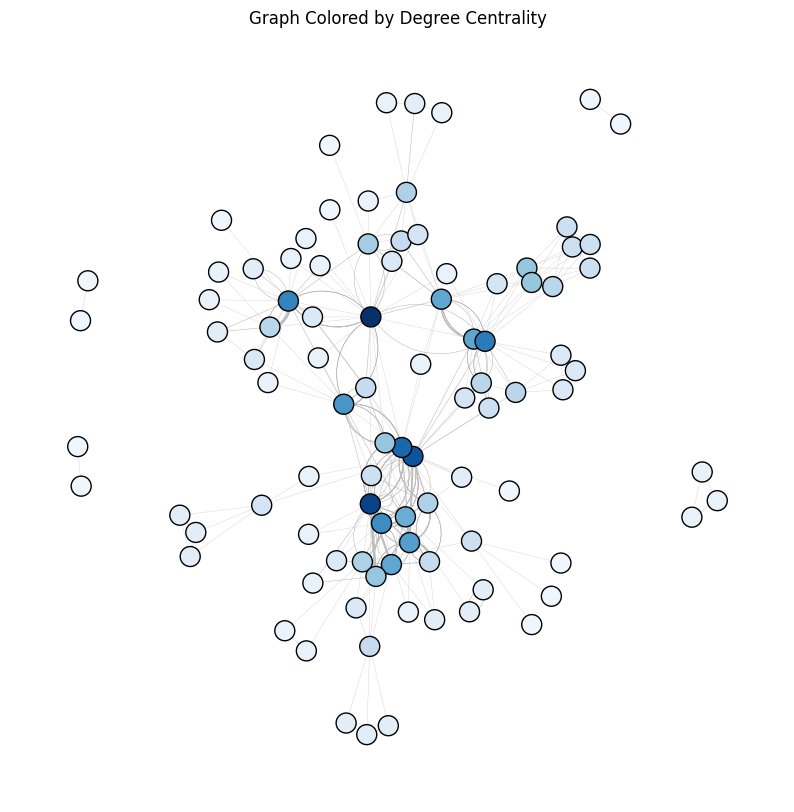

In [18]:
# Color nodes by degree
degree_colors = [plt.cm.Blues(deg / max(degrees)) for deg in degrees]

# Visualize the graph with degree-based coloring
fig, ax = plt.subplots(figsize=(10, 10))

ig.plot(
    G,
    target=ax,
    layout=layout,
    vertex_size=20,
    vertex_color=degree_colors,
    edge_width=edge_widths,
    edge_color='gray'
)

ax.set_title('Graph Colored by Degree Centrality')
plt.show()